In [1]:
import json
import typing
import ollama
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.runnables.graph import MermaidDrawMethod
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langgraph.graph import StateGraph, END
from pydantic import BaseModel 
from pprint import pprint
from IPython.display import Image, display

## Defining the open-source LLM with Ollama

In [2]:
llm_opensource = "llama3.2"

In [3]:
q = "Who are the top 10 most winners of Premier League?"

q = "Who are the top 10 latest winners of Premier League?"

In [4]:
result = ollama.chat(model = llm_opensource, 
                        messages = [{"role":"system", "content":""},
                                    {"role":"user", "content":q}])

In [5]:
print(result.message.content)

Here are the top 10 latest winners of the Premier League, along with their season and year:

1. Manchester City (2022-23)
2. Manchester City (2021-22)
3. Liverpool (2020-21)
4. Manchester City (2018-19)
5. Manchester United (2016-17)
6. Chelsea (2016-17)
7. Leicester City (2015-16)
8. Chelsea (2014-15)
9. Manchester City (2013-14)
10. Manchester United (2012-13)

Please note that the information is accurate up to the 2022-23 season and may change in future seasons.


## Defining the Tools

In the LangGraph context, tools are external functions that the graph nodes can call to execute specific tasks, such as search in the web, interact with APIs and manipulate data. They allow the LangGraph conversation flow access external funcionalities, becoming the agent more dynamical and able to handle with different kind of requests.

In [6]:
@tool("search_tool")
def search_tool(q:str) -> str:
    """Search on DuckDuckGo navigator using `q` as input"""
    return DuckDuckGoSearchRun().run(q)

In [7]:
# Testing
print(search_tool.invoke(q))

The2024-25PremierLeaguewas the 33rd season of thePremierLeagueand the 126th season oftop-flight English football overall. Manchester City entered the season as four-time defending champions, but were dethroned by Liverpool, who emerged asPremierLeaguewinnerswith four games to spare, equalling Manchester United 's record of 20 Englishleaguetitles. The fixtures were released on ... FootballBias looks at theTop10LatestWinnersinPremierLeagueHistory. In the world of football, we often talk about "Fergie Time", that mythical period of stoppage time where legends are made and hearts are broken. But yesterday at St. James' Park, Harvey Barnes didn't just play in stoppage time; he played in a different zip code. Here is the complete list of everyPremierLeaguechampion by season, plus key facts about the trophy, medals, and the most successful clubs. EnglishPremierLeagueWinnersList: The EnglishPremierLeagueis one of the most prestigious and popular footballleaguesin the world. It is the highest l

In [8]:
@tool("final_answer_tool")
def final_answer_tool(text:str) -> str:
    """
    Return a natural language answer to user using the `input text`.
    You must provide the maximum of possible context and specify the source of the information.
    """

    return text

In [9]:
# Testing
print(final_answer_tool.invoke("Test") )

Test


In [10]:
# Tools dict
dic_tools = {"search_tool":search_tool, 
             "final_answer_tool":final_answer_tool}

## Adding tools to help the decision-making process of the Agent

In [11]:
prompt = """
You are a specialist in news, you must answer all the questions of the user, you can use the tools list provided to you.
Your goal is provide the best possible answer to the user, including important informations about the sources and tools used.

Look, when you call a tool, you need to provide the name of the tool and the argument that it uses in JSON format.
For each call, you MUST use ONLY on tool and the answer format ALWAYS NEEDS to follow this patter:
```json
{"name": "<tool_name>", "parameters": "<tool_input_key>":"<tool_input_value>"}
```

You must remember, You MUST NOT use the tool with the same query more than once.
You must remember, if the user doesn't make a specific question, you MUST use the tool `final_answer_tool` directly.

Everytime the user ask you a question, you need to store in your memory.
Everytime you find some information related to user question, you have to store in your memory.

You must try collect informations from several sources before providing a answer to the user.
After collect enough informations to answer the user question, use the tool `final_answer_tool`.
"""

In [12]:
str_tools = "\n".join([str(n+1)+". `"+str(v.name)+"`: "+str(v.description) for n,v in enumerate(dic_tools.values())])

In [13]:
print(str_tools)

1. `search_tool`: Search on DuckDuckGo navigator using `q` as input
2. `final_answer_tool`: Return a natural language answer to user using the `input text`.
You must provide the maximum of possible context and specify the source of the information.


In [14]:
# Tools prompt
prompt_tools = f"You can use the following tools:\n{str_tools}"

print(prompt_tools)

You can use the following tools:
1. `search_tool`: Search on DuckDuckGo navigator using `q` as input
2. `final_answer_tool`: Return a natural language answer to user using the `input text`.
You must provide the maximum of possible context and specify the source of the information.


In [15]:
llm_answer = ollama.chat(model = llm_opensource, messages = [{"role":"system", "content":prompt+"\n"+prompt_tools}, {"role":"user", "content":q}], format = "json")

llm_answer["message"]["content"]

'{"name": "search_tool", "parameters": {"q": "{\\"key\\": \\"Premier League recent winners\\", \\"nsfw\\": false, \\"stop_words\\": \\",\\"}}}``}````, {"    \n    } \n    }'

In [16]:
content = llm_answer["message"]["content"]
data = json.loads(content)

parameters = data.get("parameters", {})
print("Keys in 'parameters':", parameters.keys())

# try to get 'q' value or the input text
tool_input = parameters.get('q') or parameters.get('input text')
if tool_input is None:
    raise KeyError("No one of the keys 'q' or 'input text' were found in 'parameter'.")

print("Value of the tool_input:", tool_input)

Keys in 'parameters': dict_keys(['q'])
Value of the tool_input: {"key": "Premier League recent winners", "nsfw": false, "stop_words": ","}}}``}````, {


In [21]:
# Testing the tool with the context
context = search_tool.invoke(tool_input)
print("Context:\n", context)

Context:
 1 day ago -Arsenal's 2024–25 campaign was heavily affected by injuries and suspensions. The club did not sign any player in the winter transfer window, after sporting director Edu Gaspar suddenly resigned midway through the season.The Gunners won twenty Premier League games in 2024–25, which was ... 2 days ago -This is an overview of all title holders of the competition Premier League in chronological order. It also shows record winners and champion managers. 11 hours ago -Find out about the format & history of the Premier League, including all previous champions, on the official website of the Premier League. 19 hours ago -Past winners includeManchester United, Blackburn Rovers, Arsenal, Chelsea, Leicester City, Liverpool, and Manchester City, with Manchester United and Manchester City noted for sustained title success. Visit the official website of the Premier League, for all the latest Premier League news and features.


## Creating the Agent Structure
On LangGraph, an agent can be developed as a class. This is useful to encapsulate the agent logic, including the nodes definition, trasitions and the memory use and tool.

When defining an agent as a class, you can:
- Structure better the source, spliting the logic and graph execution.
- Storing internal states and configure the decision flow in a more organized way.
- Facilitate the reuse and the scalability of the agent.

In [22]:
# AgentClass
class MyAgent(BaseModel):
    tool_name: str # Tool name used by the agent
    tool_input: dict # Input provided by the agent (parameters)
    tool_output: str | None = None  # Output result
    
    # Method to crate the instance from the model answer (LLM)
    @classmethod
    def from_llm(cls, res: dict):  
        try:
            out = json.loads(res["message"]["content"])
            return cls(tool_name=out["name"], tool_input=out["parameters"])
        except Exception as e:
            print(f"Ollama error:\n{res}\n")
            raise e

In [24]:
# Testing the agent
my_agent = MyAgent.from_llm(llm_answer)
print("Initial format:\n", llm_answer["message"]["content"], "\nAgent format:")
print(my_agent)

Initial format:
 {"name": "search_tool", "parameters": {"q": "{\"key\": \"Premier League recent winners\", \"nsfw\": false, \"stop_words\": \",\"}}}``}````, {"    
    } 
    } 
Agent format:
tool_name='search_tool' tool_input={'q': '{"key": "Premier League recent winners", "nsfw": false, "stop_words": ","}}}``}````, {'} tool_output=None


In [29]:
MyAgent(tool_name = "search_tool", 
        tool_input = {'q':'Who are the top 10 latest winners of Premier League?'}, 
        tool_output = str( search_tool.invoke(tool_input)))

MyAgent(tool_name='search_tool', tool_input={'q': 'Who are the top 10 latest winners of Premier League?'}, tool_output='')

## Setting the System Memory

On LangGraph, the memory refers the ability to store and retrieve informations through the conversation flow. This allows that the agent keep the context among the interactions, and adjust its answers based on previous interactions. The memory can be implemented in different ways, such as storing variables on the graph state or integrating external storage solutions.

In [30]:
# Function to generate contextual memory in th Agent 
def agent_memory(lst_res: list[MyAgent], user_q: str) -> list:
    memory = []
    
    # Iterate about the previous answers that having a valid output
    for res in [res for res in lst_res if res.tool_output is not None]:
        
        memory.extend([
            {"role": "assistant", "content": json.dumps({"name": res.tool_name, "parameters": res.tool_input})},
            {"role": "user", "content": res.tool_output}
        ])
    
    # If the memory is not empty, add a reminder of the original answer 
    if memory:
        memory += [{"role": "user", "content": (f'''
                This is only a reminder that my original query was `{user_q}`.
                Answer only the original question and nothing else, but use the informations I gave you.
                Provide the maximum of possible informations when you use the tool `final_answer`.
                ''')}]

    return memory

In [31]:
chat_history = [{"role": "user", "content": "Hi, how are you doing?"},
                {"role": "assistant", "content": "I'm great, thanks!"},
                {"role": "user", "content": "I have a question"},
                {"role": "assistant", "content": "Yes, what would you like to know?"}]

In [54]:
def execute_agent(prompt: str, dic_tools: dict, user_q: str, chat_history: list[dict], lst_res: list[MyAgent]) -> MyAgent:
    
    # Initializing the memory with the previous answers from the agent
    memory = agent_memory(lst_res = lst_res, user_q = user_q)
    
    if memory:
        tools_used = [res.tool_name for res in lst_res]
        if len(tools_used) >= len(dic_tools.keys()):
            memory[-1]["content"] = "Now you must to use the tool `final_answer_tool`."

    str_tools = "\n".join([
        f"{n+1}. `{v.name}`: {v.description}" 
        for n, v in enumerate(dic_tools.values())
    ])
    
    prompt_tools = f"You can use the following tools:\n{str_tools}"
        
    # Build the full messages list (prompt + history + memory)
    messages = [
        {"role": "system", "content": prompt + "\n" + prompt_tools},
        *chat_history,
        {"role": "user", "content": user_q},
        *memory
    ]

    llm_res = ollama.chat(model = llm_opensource, messages = messages, format = "json")

    return MyAgent.from_llm(llm_res)

In [48]:
chat_history

[{'role': 'user', 'content': 'Hi, how are you doing?'},
 {'role': 'assistant', 'content': "I'm great, thanks!"},
 {'role': 'user', 'content': 'I have a question'},
 {'role': 'assistant', 'content': 'Yes, what would you like to know?'}]

In [49]:
# Testng
agent_res = execute_agent(prompt = prompt, dic_tools = dic_tools, user_q = q, chat_history = chat_history, lst_res = [])
print("Agent answer:", agent_res)

AQUI
[{'role': 'system', 'content': '\nYou are a specialist in news, you must answer all the questions of the user, you can use the tools list provided to you.\nYour goal is provide the best possible answer to the user, including important informations about the sources and tools used.\n\nLook, when you call a tool, you need to provide the name of the tool and the argument that it uses in JSON format.\nFor each call, you MUST use ONLY on tool and the answer format ALWAYS NEEDS to follow this patter:\n```json\n{"name": "<tool_name>", "parameters": "<tool_input_key>":"<tool_input_value>"}\n```\n\nYou must remember, You MUST NOT use the tool with the same query more than once.\nYou must remember, if the user doesn\'t make a specific question, you MUST use the tool `final_answer_tool` directly.\n\nEverytime the user ask you a question, you need to store in your memory.\nEverytime you find some information related to user question, you have to store in your memory.\n\nYou must try collect i

## Creating the Graph Workflow Components

The LangGraph graph workflow is a structure that defines how the interactions flow between the graph nodes. It represents the agent logic as in a directed graph, where each node can execute a function and each edge defines possibles transictions to the next steps. 

In [50]:
# State Class
class State(typing.TypedDict):
    user_q: str
    chat_history: list 
    lst_res: list[MyAgent] # Previous answers
    output: dict

In [51]:
# Testando
state = State({"user_q":q, "chat_history":chat_history, "lst_res":[agent_res], "output":{}})
state

{'user_q': 'Who are the top 10 latest winners of Premier League?',
 'chat_history': [{'role': 'user', 'content': 'Hi, how are you doing?'},
  {'role': 'assistant', 'content': "I'm great, thanks!"},
  {'role': 'user', 'content': 'I have a question'},
  {'role': 'assistant', 'content': 'Yes, what would you like to know?'}],
 'lst_res': [MyAgent(tool_name='search_tool', tool_input={'q': 'Premier League latest winners'}, tool_output=None)],
 'output': {}}

## Node
On LangGraph, a node is a processing unit inside the Graph Workflow. Each node executes a specific function and can modify the state before passing the execution to another node.

In [59]:
def agent_node(state):
    
    print("--- Agent Node ---")
    
    agent_res = execute_agent(
        prompt = prompt, 
        dic_tools = {k: v for k, v in dic_tools.items() if k in ["search_tool", "final_answer_tool"]},
        user_q = state["user_q"], 
        chat_history = state["chat_history"], 
        lst_res = state["lst_res"]
    )
    
    print(agent_res)
    
    return {"lst_res": [agent_res]}

In [60]:
# Testing
agent_node(state)

--- Agent Node ---
tool_name='search_tool' tool_input={'q': '{"title": "Premier League Winners", "url": "https://www.premierleague.com/news/59-winners"}'} tool_output=None


{'lst_res': [MyAgent(tool_name='search_tool', tool_input={'q': '{"title": "Premier League Winners", "url": "https://www.premierleague.com/news/59-winners"}'}, tool_output=None)]}

### Specialized Node

The node tool agent_node is a specialized node on LangGraph responsible to process tools calls inside the agent flow. He works as a intermediate that:
* Identify which tool was called based on the state `(state["lst_res"][-1])`;
* Extracts and validates the necessary parameters to the tool work correctly;
* Invoke the right tool `(dic_tools[res.tool_name].invoke(tool_input))`;
* Return the right output according to the used tool.

In [67]:
def agent_node_tool(state):
    
    print("--- Agent Node Tool ---")
    res = state["lst_res"][-1]
    
    print(f"{res.tool_name}(input = {res.tool_input})")

    if res.tool_name == "final_answer_tool":
        possible_keys = ['text', 'input text', 'q']
        tool_input = None
        for key in possible_keys:
            if key in res.tool_input:
                tool_input = res.tool_input[key]
                break
        
        if not tool_input:
            raise ValueError(f"Necessary paramater to '{res.tool_name} was not found'. Expected keys: {possible_keys}. Current keys: {list(res.tool_input.keys())}")
        
        agent_res = MyAgent(
            tool_name = res.tool_name,
            tool_input = {'text': tool_input},
            tool_output = str(dic_tools[res.tool_name].invoke(tool_input))
        )
    else:
        possible_keys = ['q', 'input text', 'text']
        tool_input = None
        for key in possible_keys:
            if key in res.tool_input:
                tool_input = res.tool_input[key]
                break
        
        if not tool_input:
            raise ValueError(f"Necessary paramater to '{res.tool_name} was not found'. Expected keys: {possible_keys}. Current keys: {list(res.tool_input.keys())}")
        
        # Create the agent answer with other tools (not final_answer_tool)
        agent_res = MyAgent(
            tool_name = res.tool_name,
            tool_input = {'q': tool_input},
            tool_output = str(dic_tools[res.tool_name].invoke(tool_input))
        )

    # Returns the final output if it is 'final_answer_tool', if not, returns to continue de process
    return {"output": agent_res} if res.tool_name == "final_answer_tool" else {"lst_res": [agent_res]}

In [75]:
# Testing
agent_node_tool(state)

--- Agent Node Tool ---
search_tool(input = {'q': 'Premier League latest winners'})


{'lst_res': [MyAgent(tool_name='search_tool', tool_input={'q': 'Premier League latest winners'}, tool_output="Jun 27, 2011 ·List of all EPL (PremierLeague) titlewinnersfrom 1992 till the current season. Visit the official website of thePremierLeague, for all thelatestPremierLeaguenews and features. Check out the historicalPremierLeaguewinnerslist and find out thelatestPremierLeaguetitles by club standings. 1 day ago ·Get a sneak peek atPremierLeague'srecentchampions! Discover the previous seasonswinnersand their key stats, points and goals. Mar 25, 2026 ·EPLwinnerslist 1992 to 2025. See all 34 champions, most titles by team, records (100-point season, unbeaten), and dominant eras explained.")]}

### Conditional Edges
The conditional edges determine dynamically which node will be the next to be exectuded in the flow, based on the current state. They allow the graph follow different paths depending the definitive logic. 

In [77]:
def condicional_edges(state):
    print("--- Edges Condicionais ---")
    
    last_res = state["lst_res"][-1]
    # Decides which node will be the next based the used tool 
    next_node = last_res.tool_name if isinstance(state["lst_res"], list) else "final_answer_tool"
    
    print("Next Node:", next_node)    
    return next_node

In [93]:
# Testing
condicional_edges(state)

--- Edges Condicionais ---
Next Node: search_tool


'search_tool'

### Creating the Graph

In [94]:
# Initializing the state graph using the class State
workflow = StateGraph(State)

# Adding the main node on the workflow agent
workflow.add_node(node = "MyAgent", action = agent_node)

# Defining the input point of the workflow
workflow.set_entry_point(key = "MyAgent")

# Add the specializeds node of the available tools  
for k in dic_tools.keys():
    workflow.add_node(node = k, action = agent_node_tool)

workflow.add_conditional_edges(source = "MyAgent", path = condicional_edges)

for k in dic_tools.keys():
    if k != "final_answer_tool":
        workflow.add_edge(start_key = k, end_key = "MyAgent")

# Define a final edge that ends the workflow after executing the 'final_answer_tool' tool
workflow.add_edge(start_key = "final_answer_tool", end_key = END)

# Compile the workflow to execute
g = workflow.compile()

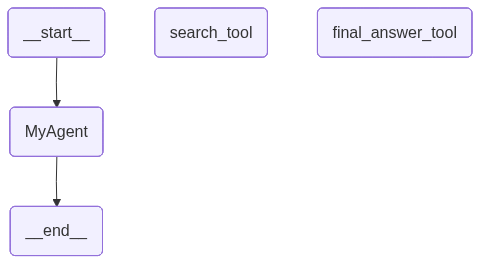

In [95]:
# Showing the workflow
display(Image(g.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)))

## Running the workflow with only one agent

In [96]:
initial_state = {'user_q':q,
                 'chat_history':chat_history, 
                 'lst_res':[],
                 'output':{} }

In [97]:
out = g.invoke(input = initial_state)
agent_out = out['output'].tool_output

--- Agent Node ---
tool_name='search_tool' tool_input={'q': 'latest premier league winners list'} tool_output=None
--- Edges Condicionais ---
Next Node: search_tool
--- Agent Node Tool ---
search_tool(input = {'q': 'latest premier league winners list'})
--- Agent Node ---
tool_name='search_tool' tool_input={'q': 'top 10 latest winners premier league'} tool_output=None
--- Edges Condicionais ---
Next Node: search_tool
--- Agent Node Tool ---
search_tool(input = {'q': 'top 10 latest winners premier league'})
--- Agent Node ---
tool_name='search_tool' tool_input={'q': 'top 10 latest winners premier league'} tool_output=None
--- Edges Condicionais ---
Next Node: search_tool
--- Agent Node Tool ---
search_tool(input = {'q': 'top 10 latest winners premier league'})
--- Agent Node ---
tool_name='search_tool' tool_input={'q': 'top 10 latest winners premier league'} tool_output=None
--- Edges Condicionais ---
Next Node: search_tool
--- Agent Node Tool ---
search_tool(input = {'q': 'top 10 lates

In [98]:
print("Answer of the Agent on Initial State")
agent_out

Answer of the Agent on Initial State


'The top 10 latest winners of Premier League are: \n1. Manchester City (2022-23)\n2. Manchester City (2021-22)\n3. Liverpool (2020-21)\n4. Liverpool (2019-20)\n5. Arsenal (2018-19)\n6. Chelsea (2017-18)\n7. Leicester City (2016-17)\n8. Leicester City (2015-16)\n9. Tottenham Hotspur (2015-16)\n10. Chelsea (2014-15)'